In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.metrics import confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import xgboost as xgb
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format) # control decimal
sns.set_theme(style='whitegrid', palette='colorblind') # helps graphs be more legible and colorblind safe
palette = sns.color_palette('colorblind') # color consistency in matplotlib plots
CB_BLUE = palette[0]   # blue
CB_ORANGE = palette[1]   # orange
random_state = 2026

In [2]:
# import data
global df
df = pd.read_csv('./support_tickets_10000.csv', keep_default_na=False)
df.head(5)

,ticket_id,customer_segment,product_area,priority,channel,agent_tenure_months,first_response_min,resolution_min,reopen_count,csat_1_5,refund_requested,escalation,bug_confirmed,sentiment_score,sla_breached
0,200000,Enterprise,mobile,medium,email,11.0000,169.2000,1859.7000,0,3,0,0,0,-0.1940,1
1,200001,Consumer,api,low,phone,2.9000,5.6000,701.5000,0,5,0,0,0,0.4790,0
2,200002,Consumer,integrations,medium,email,5.3000,37.0000,724.5000,0,4,0,0,1,0.0390,1
3,200003,SMB,billing,low,phone,10.3000,22.4000,539.5000,0,5,0,0,0,-0.1460,0
4,200004,Enterprise,integrations,low,chat,16.2000,47.0000,1142.8000,2,3,0,0,1,-0.4760,0


In [3]:
# get shape
df.shape

(10000, 15)

In [4]:
# get data types
df.dtypes

ticket_id                int64
customer_segment        object
product_area            object
priority                object
channel                 object
agent_tenure_months    float64
first_response_min     float64
resolution_min         float64
reopen_count             int64
csat_1_5                 int64
refund_requested         int64
escalation               int64
bug_confirmed            int64
sentiment_score        float64
sla_breached             int64
dtype: object

In [5]:
# check for nulls
df.isnull().sum()

ticket_id              0
customer_segment       0
product_area           0
priority               0
channel                0
agent_tenure_months    0
first_response_min     0
resolution_min         0
reopen_count           0
csat_1_5               0
refund_requested       0
escalation             0
bug_confirmed          0
sentiment_score        0
sla_breached           0
dtype: int64

In [6]:
# get overview of dataset
df.head()

,ticket_id,customer_segment,product_area,priority,channel,agent_tenure_months,first_response_min,resolution_min,reopen_count,csat_1_5,refund_requested,escalation,bug_confirmed,sentiment_score,sla_breached
0,200000,Enterprise,mobile,medium,email,11.0000,169.2000,1859.7000,0,3,0,0,0,-0.1940,1
1,200001,Consumer,api,low,phone,2.9000,5.6000,701.5000,0,5,0,0,0,0.4790,0
2,200002,Consumer,integrations,medium,email,5.3000,37.0000,724.5000,0,4,0,0,1,0.0390,1
3,200003,SMB,billing,low,phone,10.3000,22.4000,539.5000,0,5,0,0,0,-0.1460,0
4,200004,Enterprise,integrations,low,chat,16.2000,47.0000,1142.8000,2,3,0,0,1,-0.4760,0


In [7]:
# basic var stats
df.describe()

,ticket_id,agent_tenure_months,first_response_min,resolution_min,reopen_count,csat_1_5,refund_requested,escalation,bug_confirmed,sentiment_score,sla_breached
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,204999.5000,21.8949,59.7679,696.5463,0.2795,4.1641,0.0554,0.0909,0.2870,0.1084,0.3656
std,2886.8957,14.7652,98.6500,638.9601,0.5525,0.7043,0.2288,0.2875,0.4524,0.3358,0.4816
min,200000.0000,0.2000,1.2000,23.6000,0.0000,1.0000,0.0000,0.0000,0.0000,-1.0000,0.0000
25%,202499.7500,11.0000,10.0000,293.0500,0.0000,4.0000,0.0000,0.0000,0.0000,-0.0960,0.0000
50%,204999.5000,18.7000,24.2000,511.7500,0.0000,4.0000,0.0000,0.0000,0.0000,0.1270,0.0000
75%,207499.2500,29.2000,65.5000,887.1500,0.0000,5.0000,0.0000,0.0000,1.0000,0.3440,1.0000
max,209999.0000,115.8000,1440.0000,8775.9000,5.0000,5.0000,1.0000,1.0000,1.0000,1.0000,1.0000


---
## Exploratory Data Analysis (EDA)

### Target Variable Distribution

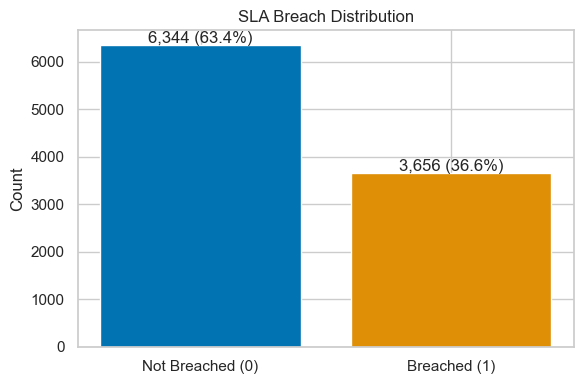

SLA Breach rate: 0.3656 (36.6%)


In [9]:
# exploring the target variable - does it look reasonably distributed
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['sla_breached'].value_counts()
ax.bar(['Not Breached (0)', 'Breached (1)'], counts.values, color=[CB_BLUE, CB_ORANGE])
ax.set_title('SLA Breach Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values): # percentages on bar is prettier and easy to interpret
    ax.text(i, v + 50, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.show()
print(f'SLA Breach rate: {df["sla_breached"].mean():.4f} ({df["sla_breached"].mean()*100:.1f}%)')

### SLA Threshold Analysis

Though not required for model development, determining a possible SLA target deadline could provide some context for the relationship between priority and SLA breach. That relationship could prove useful in model interpretation. Subsets of each priority and their respective sla_breached values will be stored then split into breached and not breached. The maximum resolution_min for the not breached records and the minimum resolution_min for the breached records will be recorded to see what the SLA target deadlines may look like.

In [11]:
print('Estimated SLA resolution thresholds by priority:')
print()
for priority in ['low', 'medium', 'high', 'urgent']:
    subset = df[df['priority'] == priority] # create the subsets for each priority category
    met = subset[subset['sla_breached'] == 0] # subset of the subset for each priority w no sla breach
    breached = subset[subset['sla_breached'] == 1] # same as above but w sla breach
    print(f'{priority.upper():8s}  |  ' # the padding makes it pretty
          f'Met max resolution: {met["resolution_min"].max():>7.1f} min  |  '
          f'Breached min resolution: {breached["resolution_min"].min():>7.1f} min')

Estimated SLA resolution thresholds by priority:

LOW       |  Met max resolution:  1434.4 min  |  Breached min resolution:  1440.9 min
MEDIUM    |  Met max resolution:   719.9 min  |  Breached min resolution:   720.6 min
HIGH      |  Met max resolution:   359.0 min  |  Breached min resolution:   360.0 min
URGENT    |  Met max resolution:   177.8 min  |  Breached min resolution:   180.1 min


Based on the above output, there appears to be a resolution time target for each different priority level of tickets.
- Low priority: less than 1440 minutes
- Medium priority: less than 720 minutes
- High priority: less than 360 minutes
- Urgent priority: less than 180 minutes

With nothing else to go off of, the above is reasonable to assume. This relationship will be examined more during model interpretation.

### Breach Rate by Categorical Features

Any features that could only be available in late life-cycle of a ticket or post resolution like resolution_min, csat_1_5, reopen_count, etc will not be used in the models. By the time those features are available for a support ticket, SLA breach will usually already be determined. So, as not to poison the model by allowing it to "cheat", those features will not be included in the working feature sets. Only features available at ticket creation time will be included. Below shows the breach rate of categorical features that would be available at ticket creation time.

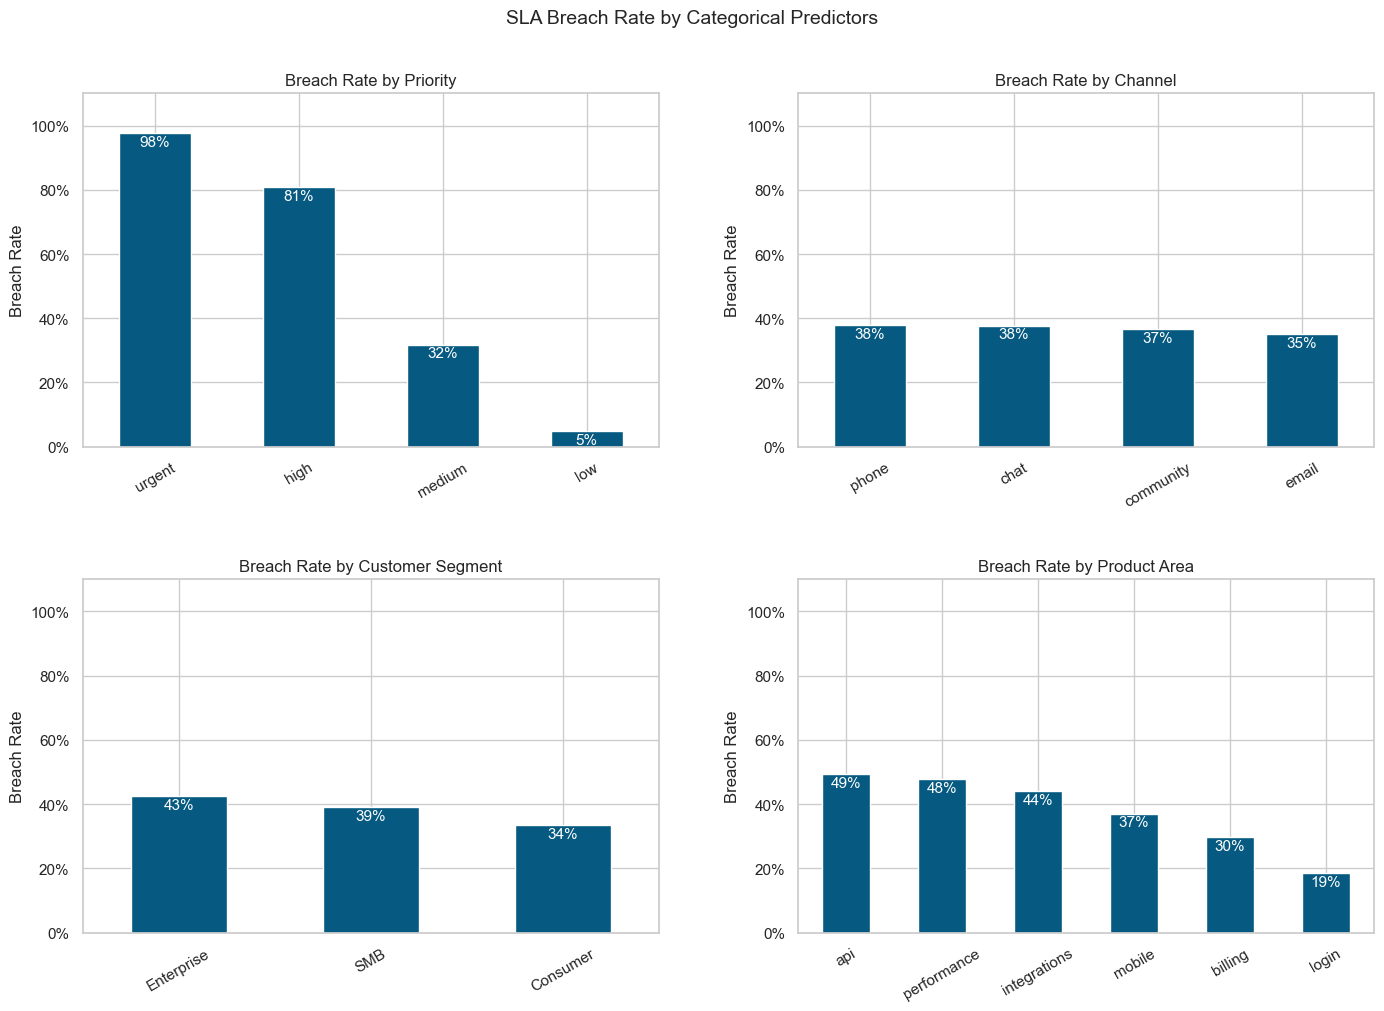

In [14]:
from matplotlib.ticker import PercentFormatter

categorical_cols = ['priority', 'channel', 'customer_segment', 'product_area'] # only use those which would be available at ticket creation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), categorical_cols):
    breach_rate = df.groupby(col)['sla_breached'].mean().sort_values(ascending=False)
    breach_rate.plot(kind='bar', ax=ax, color='#065A82', edgecolor='white')
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.set_title(f'Breach Rate by {col.replace("_", " ").title()}')
    ax.set_ylabel('Breach Rate')
    ax.set_xlabel('') # too crowded without this
    ax.set_ylim(0, 1.1) # urgent too close to 1.0
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{p.get_height()*100:.0f}%',
                    (p.get_x() + p.get_width()/2, p.get_height() - 0.04),
                    ha='center', fontsize=11, color='white')

plt.suptitle('SLA Breach Rate by Categorical Predictors', fontsize=14, y=1.01)
plt.tight_layout(h_pad=3, w_pad=4) # way less cramped w padding
plt.show()

### Continuous Variable Distributions and Skewness

Only continuous variables that would be available at ticket creation are explored. Variables are checking for normal distribution and skewness. 

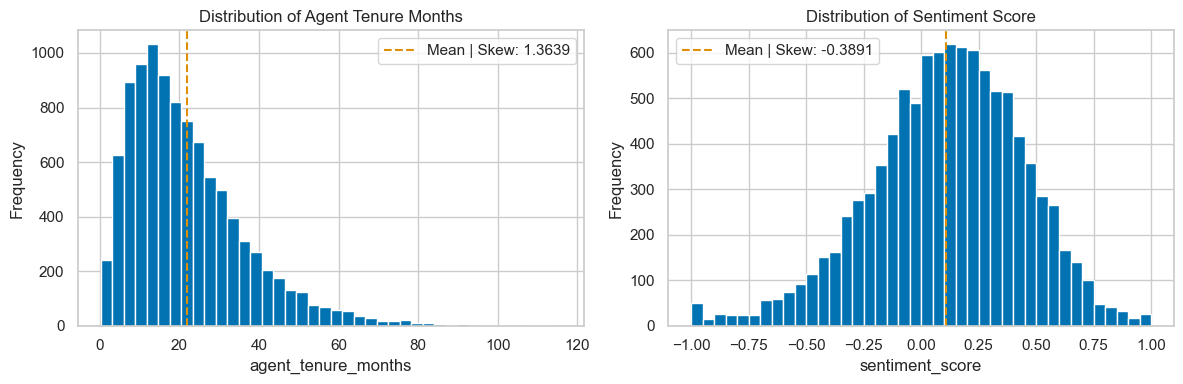

Skewness and Shapiro-Wilk test (sample n=1000):
  agent_tenure_months: skew=1.3639, W=0.8923, p=0.0000
  sentiment_score: skew=-0.3891, W=0.9862, p=0.0000


In [16]:
continuous_cols = ['agent_tenure_months', 'sentiment_score']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, continuous_cols):
    ax.hist(df[col], bins=40, color=CB_BLUE, edgecolor='white')
    ax.set_title(f'Distribution of {col.replace("_", " ").title()}') # pretty title names
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    skew = df[col].skew()
    ax.axvline(df[col].mean(), color=CB_ORANGE, linestyle='--',
               label=f'Mean | Skew: {skew:.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

print('Skewness and Shapiro-Wilk test (sample n=1000):')
for col in continuous_cols:
    stat, p = stats.shapiro(df[col].sample(1000, random_state=42))
    print(f'  {col}: skew={df[col].skew():.4f}, W={stat:.4f}, p={p:.4f}')

## Feature Selection and Pre-Processing

In [18]:
# only features available at ticket creation time
feature_cols = ['customer_segment', 'product_area', 'priority', 'channel',
            'agent_tenure_months', 'sentiment_score']
target_col = 'sla_breached'

X = df[feature_cols].copy()
y = df[target_col].copy()

print(X.shape)
print()
print(y.value_counts())

(10000, 6)

sla_breached
0    6344
1    3656
Name: count, dtype: int64


Original skew: 1.3639
Transformed skew: -0.4387


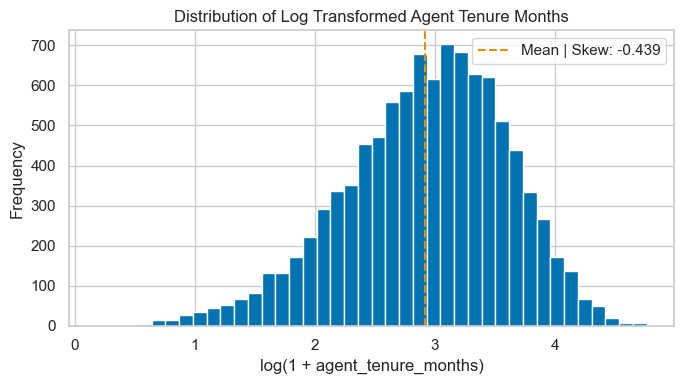

In [19]:
# log transform agent_tenure_months for skew
X['agent_tenure_months_log'] = np.log1p(X['agent_tenure_months'])
X = X.drop(columns=['agent_tenure_months'])

# verify
print(f'Original skew: 1.3639')
print(f'Transformed skew: {X["agent_tenure_months_log"].skew():.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(X['agent_tenure_months_log'], bins=40, color=CB_BLUE, edgecolor='white')
skew = X['agent_tenure_months_log'].skew()
ax.axvline(X['agent_tenure_months_log'].mean(), color=CB_ORANGE, linestyle='--',
           label=f'Mean | Skew: {skew:.3f}')
ax.set_title(f'Distribution of Log Transformed Agent Tenure Months')
ax.set_xlabel('log(1 + agent_tenure_months)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

### One-Hot Encoding

In [21]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(X_encoded.shape)
print()
print(X_encoded.columns.tolist())

(10000, 15)

['sentiment_score', 'agent_tenure_months_log', 'priority_low', 'priority_medium', 'priority_urgent', 'channel_community', 'channel_email', 'channel_phone', 'customer_segment_Enterprise', 'customer_segment_SMB', 'product_area_billing', 'product_area_integrations', 'product_area_login', 'product_area_mobile', 'product_area_performance']


### Ordinal Encoding for Priority (Comparison)

An alternate option using ordinal encoding for priority will be used to test the model and see which method works best or if it even makes a difference at all.

In [23]:
priority_order = {'low': 1, 'medium': 2, 'high': 3, 'urgent': 4}
X_ordinal = X.copy()
X_ordinal['priority_ordinal'] = X_ordinal['priority'].map(priority_order)
X_ordinal = pd.get_dummies(
    X_ordinal.drop(columns=['priority']),
    columns=['customer_segment', 'product_area', 'channel'],
    drop_first=True)

print(X_ordinal.shape)
print()
print(X_ordinal.columns.tolist())

(10000, 13)

['sentiment_score', 'agent_tenure_months_log', 'priority_ordinal', 'customer_segment_Enterprise', 'customer_segment_SMB', 'product_area_billing', 'product_area_integrations', 'product_area_login', 'product_area_mobile', 'product_area_performance', 'channel_community', 'channel_email', 'channel_phone']


### Multicollinearity Check (VIF)

In [25]:
X_vif = X_encoded.copy().astype(float)
vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))

                    Feature    VIF
    agent_tenure_months_log 8.5885
               priority_low 2.5963
            priority_medium 2.4097
         product_area_login 2.2991
              channel_email 2.1220
       product_area_billing 2.1124
   product_area_performance 2.0830
        product_area_mobile 1.9834
  product_area_integrations 1.9773
       customer_segment_SMB 1.5215
              channel_phone 1.5021
          channel_community 1.2980
customer_segment_Enterprise 1.2630
            priority_urgent 1.2541
            sentiment_score 1.2364


Agent_tenure_months has a high VIF that could be explained by a few possiblities:
1. Longer tenured agents being assigned to higher-priority channel tickets or specific channel/product areas.
2. The log transformation introduce some patterns that weren't there before.

8.59 is still below 10 which, while high, does not require removal. The multicollinearity is moderate but still acceptable. All other features have VIF values below 3 which suggest low multicollinearity.

### Train / Test Split (80/20, Stratified)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=2026, stratify=y)

X_train_ord, X_test_ord, _, _ = train_test_split( # blanks because i don't know the test one; ordinal encoding comparison train set
    X_ordinal, y, test_size=0.2, random_state=2026, stratify=y)

print(f'Train: {X_train.shape[0]} rows  |  breach rate: {y_train.mean():.4f}') # make sure this is same and stratify worked
print(f'Test:  {X_test.shape[0]} rows   |  breach rate: {y_test.mean():.4f}')

Train: 8000 rows  |  breach rate: 0.3656
Test:  2000 rows   |  breach rate: 0.3655


---
## Model Building

### Logistic Regression

In [30]:
lr_model = LogisticRegressionCV(
    Cs=10, cv=5, scoring='accuracy',
    random_state=2026, max_iter=1000, n_jobs=-1)

lr_model.fit(X_train, y_train)

print(f'Best C (regularization): {lr_model.C_[0]:.4f}')
print(f'Mean CV Accuracy:        {lr_model.scores_[1].mean():.4f}')

Best C (regularization): 0.3594
Mean CV Accuracy:        0.8287


A C of 2.78 indicates that model only needed some mild regulation. 
A ROC-AUC of 0.94 is very high. As long as the ROC-AUC is very high when fitting the test set, the model is performing well. Performing high on the training set could be indicative of data leakage. A possibility is that sentiment_score is not actually available at ticket creation as a score on the original ticket message but calculated at resolution based on the entire conversation. If the ROC-AUC score drops significantly using the test set, sentiment_score will be removed as a feature.

### XGBoost

In [33]:
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='error',
    random_state=2026,
    n_jobs=-1,
    #use_label_encoder=False # removed 2026-07
)

param_grid = { # 16 combos
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_cv = GridSearchCV(xgb_base, param_grid, cv=5,
                      scoring='accuracy', n_jobs=-1, verbose=0)
xgb_cv.fit(X_train, y_train)

print('Best parameters:', xgb_cv.best_params_)
print(f'ACCURACY:      {xgb_cv.best_score_:.4f}')

best_xgb = xgb_cv.best_estimator_

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
ACCURACY:      0.8759


---
## Model Evaluation

### ROC Curves

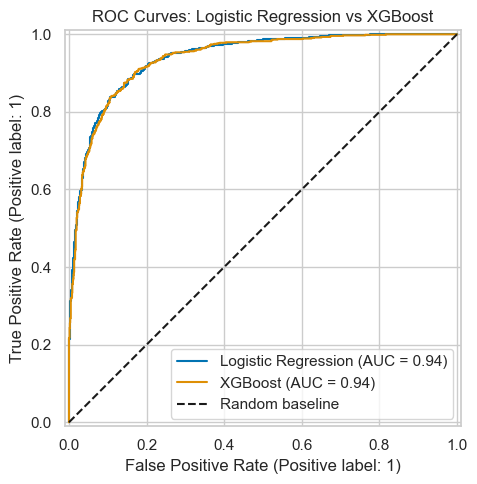

Logistic Regression ROC-AUC: 0.9396
XGBoost ROC-AUC:             0.9380


In [35]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(lr_model, X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(best_xgb, X_test, y_test, ax=ax, name='XGBoost')
ax.plot([0,1],[0,1], 'k--', label='Random baseline')
ax.set_title('ROC Curves: Logistic Regression vs XGBoost')
ax.legend()
plt.tight_layout()
plt.show()

lr_auc  = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])
xgb_auc = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])
print(f'Logistic Regression ROC-AUC: {lr_auc:.4f}')
print(f'XGBoost ROC-AUC:             {xgb_auc:.4f}')

### Classification Reports

In [37]:
print('<Logistic Regression>')
print(classification_report(y_test, lr_model.predict(X_test),
                             target_names=['Not Breached', 'Breached']))

print('<XGBoost>')
print(classification_report(y_test, best_xgb.predict(X_test),
                             target_names=['Not Breached', 'Breached']))

<Logistic Regression>
              precision    recall  f1-score   support

Not Breached       0.89      0.92      0.90      1269
    Breached       0.85      0.80      0.82       731

    accuracy                           0.87      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.87      0.87      0.87      2000

<XGBoost>
              precision    recall  f1-score   support

Not Breached       0.89      0.91      0.90      1269
    Breached       0.83      0.80      0.82       731

    accuracy                           0.87      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.87      0.87      0.87      2000



Both models had high ROC-AUC and precision while recall on the Breached class was lower. With Breached being the more important class, that difference matters. The models are missing roughly 20% of breached tickets. That's 1 in 5 SLA breaches going undetected. In the dataset, the Breach class is in the minority at 37%, so it makes sense that the models are better at predicting the majority class, Not Breached. An adjustment to the prediction threshold could improve the models, but that is outside the scope of this study. Both models achieve 87% accuracy.

### Confusion Matrices

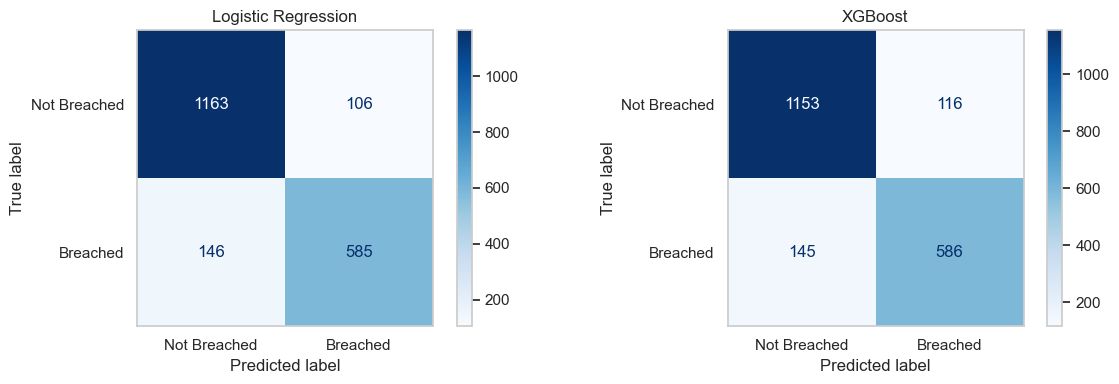

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, model, name in zip(axes,
                            [lr_model, best_xgb],
                            ['Logistic Regression', 'XGBoost']):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['Not Breached', 'Breached'],
        cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.grid(False) # so the number are clear
plt.tight_layout()
plt.show()

### Performance Summary

In [42]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_model.predict(X_test)),
        accuracy_score(y_test, best_xgb.predict(X_test))
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])
    ],
    'Precision': [
        precision_score(y_test, lr_model.predict(X_test)),
        precision_score(y_test, best_xgb.predict(X_test))
    ],
    'Recall': [
        recall_score(y_test, lr_model.predict(X_test)),
        recall_score(y_test, best_xgb.predict(X_test))
    ],
    'F1-Score': [
        f1_score(y_test, lr_model.predict(X_test)),
        f1_score(y_test, best_xgb.predict(X_test))
    ]
})
print(results.round(4).to_string(index=False))
print()
print() # prettier

# easier to read quickly
for model, name in [(lr_model, 'Logistic Regression'),
                     (best_xgb, 'XGBoost')]:
    cm = confusion_matrix(y_test, model.predict(X_test))
    tn, fp, fn, tp = cm.ravel()
    
    print(f'<{name}>')
    print(f'               Predicted')
    print(f'                     Not Breached  Breached')
    print(f'Actual Not Breached    {tn:5d}      {fp:5d}')
    print(f'Actual Breached        {fn:5d}      {tp:5d}')
    print()

              Model  Accuracy  ROC-AUC  Precision  Recall  F1-Score
Logistic Regression    0.8740   0.9396     0.8466  0.8003    0.8228
            XGBoost    0.8695   0.9380     0.8348  0.8016    0.8179


<Logistic Regression>
               Predicted
                     Not Breached  Breached
Actual Not Breached     1163        106
Actual Breached          146        585

<XGBoost>
               Predicted
                     Not Breached  Breached
Actual Not Breached     1153        116
Actual Breached          145        586



---
## Feature Importance

### Logistic Regression Coefficients and Odds Ratios

                    Feature  Coefficient  Odds Ratio
            priority_urgent       2.4011     11.0356
customer_segment_Enterprise       0.6098      1.8401
       customer_segment_SMB       0.3050      1.3567
          channel_community       0.0769      1.0799
              channel_phone       0.0180      1.0182
              channel_email      -0.0674      0.9348
   product_area_performance      -0.0894      0.9145
    agent_tenure_months_log      -0.1218      0.8853
  product_area_integrations      -0.4519      0.6364
        product_area_mobile      -0.9575      0.3839
       product_area_billing      -1.5340      0.2157
         product_area_login      -2.5023      0.0819
            priority_medium      -2.6513      0.0706
            sentiment_score      -3.8037      0.0223
               priority_low      -5.2042      0.0055


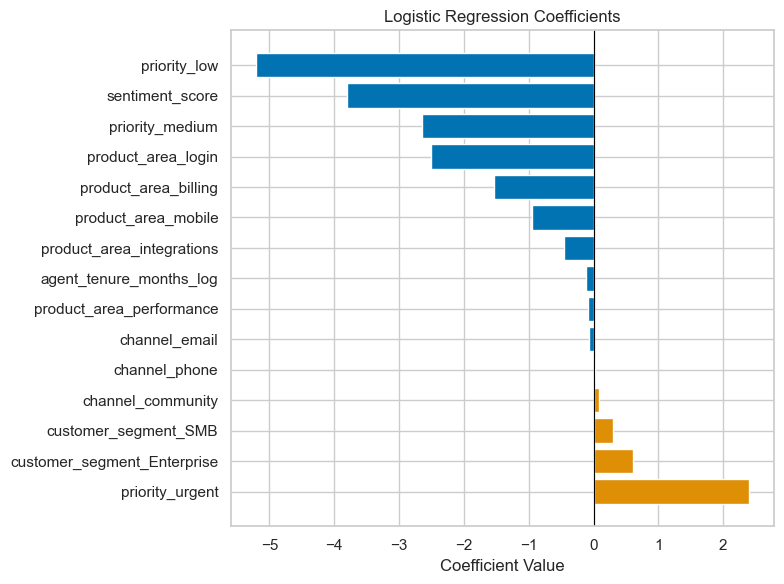

In [44]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0],
    'Odds Ratio': np.exp(lr_model.coef_[0])
}).sort_values('Coefficient', ascending=False)

print(coef_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
colors = [CB_ORANGE if c > 0 else CB_BLUE for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

Priority_urgent stands out as having the highest influence on SLA breach. Urgent tickets breach odds are ~20 times the breach odds of the reference category (priority_high). That is incredibly significant and makes sense given the result of the exploratory SLA resolution_min target analysis in cell [11]. Assuming those resolution_min thresholds are in fact SLA targets, urgent priority tickets would have a 3-hour resolution window while low priority tickets have a 24-hour resolution window. Shorter window = easier to breach SLA. Priority_low having a very low odds ratio makes sense given that assumption as well.

Sentiment_score has a very strong negative effect on SLA breach. with an odds ratio of 0.015, each 1-unit increase in sentiment_score decreases the odds of SLA breach by ~98%. This could be legitimate, or it could be another sign of data leakage. Assuming sentiment_score is based on the ticket at creation, it's possible that frustrated customers may be filing tickets for more complex or higher urgency issues resulting in a longer resolution time. However, if sentiment_score is based on the ticket post resolution, the models are able to "cheat" by knowing a ticket resolution went poorly (negative customer sentiment). With this being the second indication of possible data leakage, it's worth investigating.

Other noteable features include:
- customer_segment: enterprise and SMB customers have higher breach odds (1.971, 1.397) compared to the reference category (consumer)
  - could be due to enterprise and SMB customers having more complex issues, stricter SLAs, or both
- product_area:
  - login and billing have very low breach odds (0.052, 0.156)
  - mobile and integrations have low-moderate breach odds (0.296, 0.517)
  - performance breach odds are only slightly negative (0.767)
  - the reference product area (api) appears to have fairly neutral breach odds
- channel categories and agent_tenure_months have very little effect on SLA breach
  - channel category odds are all ~1
  - agent_tenure_months has a very small negative effect (0.871) implying that more experienced agents experience slightly fewer breaches.
    - Longer tenured agents likely handle more complex issues which could explain the very small effect on SLA breach. Longer tenured agents may be able to reach resolution quicker than less experienced agents, but they are given more complicated and time-consuming problems which bridge the gap.

### XGBoost Feature Importance

                    Feature  Importance
               priority_low     36.0670
            priority_medium     29.8327
            sentiment_score      6.4288
            priority_urgent      6.0799
         product_area_login      6.0604
       product_area_billing      3.6989
   product_area_performance      2.8431
        product_area_mobile      1.8939
customer_segment_Enterprise      1.6238
       customer_segment_SMB      1.1432
  product_area_integrations      0.9699
    agent_tenure_months_log      0.8989
          channel_community      0.8920
              channel_email      0.7854
              channel_phone      0.7819


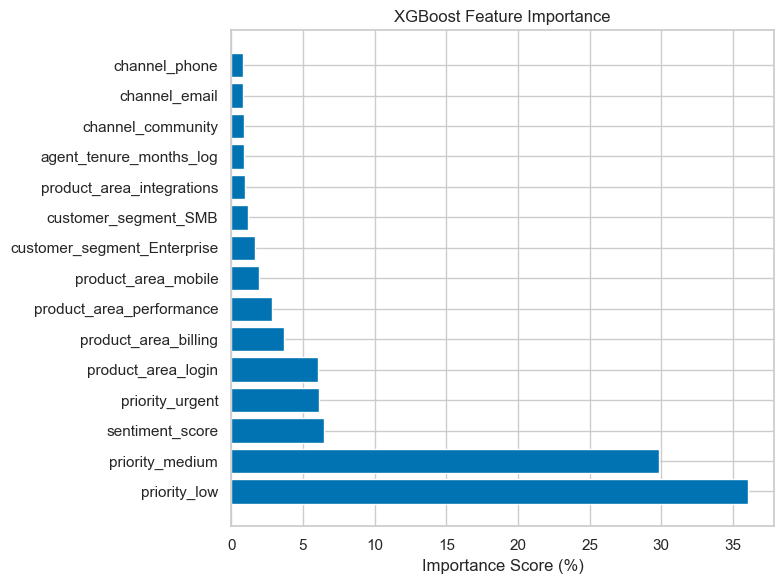

In [47]:
xgb_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_ * 100
}).sort_values('Importance', ascending=False)

print(xgb_imp.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(xgb_imp['Feature'], xgb_imp['Importance'], color=CB_BLUE)
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance Score (%)')
plt.tight_layout()
plt.show()

Priority stands out as the most useful measure. Low, medium, and urgent priority account for 72% of the total feature importance in the XGBoost model. Sentiment_score has an importance score of only 0.064. Sentiment_score is not insignificant, but it is drastically less significant than priority_low (0.361) and priority_medium (0.298). With XGBoost showing less significance in sentiment_score, the argument to investigate more has weakened. 

Product area categories are showing up as significant predictors at ~15% of the total feature importance. Customer segment is less impactful at ~2% of total feature importance. Agent_tenure_months has very little affect at just under 1% importance. Channel categories area all slightly more under `% than agent_tenure_months.

Compared to the LR model, these results focus only on how important a feature is without direction or magnitude of its effect on SLA breach. XGBoost can handle more complex, nonlinear relationship but is limited in immediately interpretable output. The LR model provided more detailed information about the quality of the effect each feature has on SLA breach but is limited to linear relationship. A byproduct of that contraint is that sentiment_score's effect may have been exaggerated. The XGBoost model results lessened some of the concern over data leakage, but a robustness check could still help to solidify whether or not sentiment_score is creating issues or if it's just a side effect of logistic regression limitations. At this time, that is outside the scope of this study.

### Normalized Feature Importance Comparison

In [50]:
lr_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'LR_abs_coef': np.abs(lr_model.coef_[0])
})
lr_imp['LR_normalized'] = lr_imp['LR_abs_coef'] / lr_imp['LR_abs_coef'].sum()

xgb_imp['XGB_normalized'] = xgb_imp['Importance'] / xgb_imp['Importance'].sum() # just in case

comparison = lr_imp[['Feature', 'LR_normalized']].merge(
    xgb_imp[['Feature', 'XGB_normalized']], on='Feature')

comparison = comparison.sort_values('LR_normalized')
print(comparison.round(4).to_string(index=False))

                    Feature  LR_normalized  XGB_normalized
              channel_phone         0.0009          0.0078
              channel_email         0.0032          0.0079
          channel_community         0.0037          0.0089
   product_area_performance         0.0043          0.0284
    agent_tenure_months_log         0.0059          0.0090
       customer_segment_SMB         0.0147          0.0114
  product_area_integrations         0.0217          0.0097
customer_segment_Enterprise         0.0293          0.0162
        product_area_mobile         0.0460          0.0189
       product_area_billing         0.0738          0.0370
            priority_urgent         0.1155          0.0608
         product_area_login         0.1203          0.0606
            priority_medium         0.1275          0.2983
            sentiment_score         0.1829          0.0643
               priority_low         0.2503          0.3607


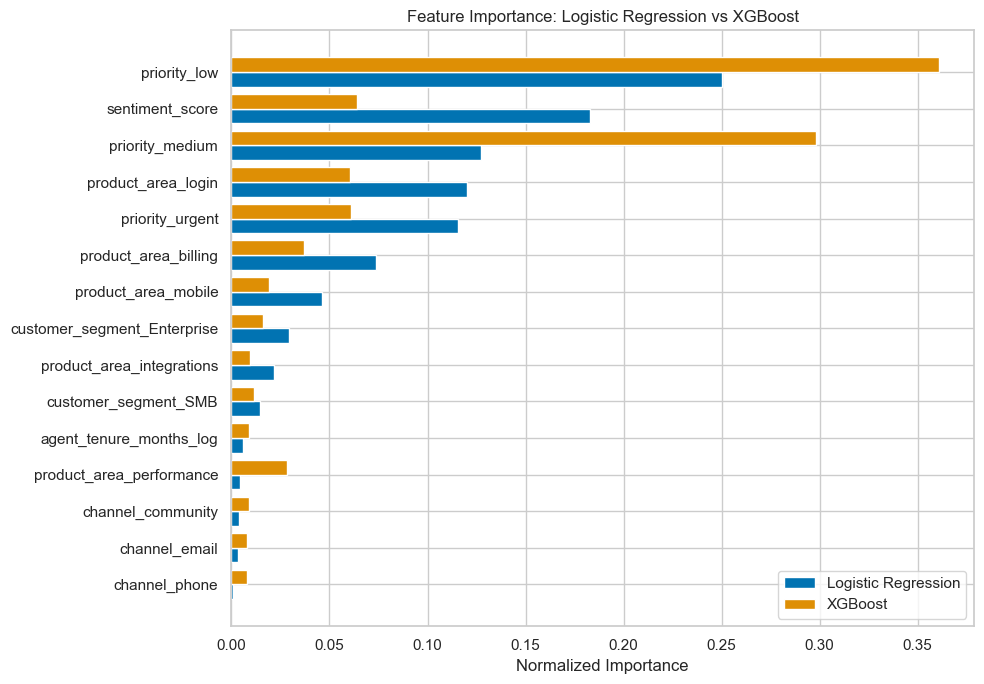

In [51]:
import numpy as np
fig, ax = plt.subplots(figsize=(10, 7))

comparison_sorted = comparison.sort_values('LR_normalized', ascending=True)
y_pos = np.arange(len(comparison_sorted))
width = 0.4

ax.barh(y_pos - width/2, comparison_sorted['LR_normalized'],
        width, label='Logistic Regression', color=CB_BLUE)
ax.barh(y_pos + width/2, comparison_sorted['XGB_normalized'],
        width, label='XGBoost', color=CB_ORANGE)

ax.set_yticks(y_pos)
ax.set_yticklabels(comparison_sorted['Feature'])
ax.set_xlabel('Normalized Importance')
ax.set_title('Feature Importance: Logistic Regression vs XGBoost')
ax.legend()
plt.tight_layout()
plt.show()

Priority dominates in both models as the most important predictor. Sentiment_score contributes greatly, as well, but XGBoost ranks it lower than LR does. Product area, specifically login and billing, are moderately important predictors. Channel and agent tenure have very little value in terms of predicting SLA breach. Both models agree overall on which features contribute most to SLA breach strengthening each individual model's findings. 

---
## Robustness Check - Sentiment_score

Though XGBoost's lower ranking of sentiment_score suggested a lower likelihood of data leakage, a robustness check can be done. If eliminating sentiment_score as a feature drastically drops the AUC, then data leakage is more likely. If the drop is minimal, then data leakage is very unlikely.

In [54]:
# feature set without sentiment_score
features_no_sent = [c for c in feature_cols if c != 'sentiment_score']
X_no_sent = df[features_no_sent].copy()

# log transformation
X_no_sent['agent_tenure_months_log'] = np.log1p(X_no_sent['agent_tenure_months'])
X_no_sent = X_no_sent.drop(columns=['agent_tenure_months'])

# encoding categoricals 
X_no_sent_encoded = pd.get_dummies(X_no_sent, columns=categorical_cols, drop_first=True)

# train/test split
X_train_ns, X_test_ns, _, _ = train_test_split(
    X_no_sent_encoded, y, test_size=0.2, random_state=2026, stratify=y)

# refit LR model
lr_no_sent = LogisticRegressionCV(
    Cs=10, cv=5, scoring='accuracy',
    random_state=2026, max_iter=1000, n_jobs=-1)
lr_no_sent.fit(X_train_ns, y_train)

# refit XGB
xgb_no_sent_cv = GridSearchCV(xgb_base, param_grid, cv=5,
                               scoring='accuracy', n_jobs=-1)
xgb_no_sent_cv.fit(X_train_ns, y_train)
xgb_no_sent = xgb_no_sent_cv.best_estimator_

# compare results
lr_acc_full = accuracy_score(y_test, lr_model.predict(X_test))
lr_acc_no_sent = accuracy_score(y_test, lr_no_sent.predict(X_test_ns))

xgb_acc_full = accuracy_score(y_test, best_xgb.predict(X_test))
xgb_acc_no_sent = accuracy_score(y_test, xgb_no_sent.predict(X_test_ns))

robustness = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Accuracy (full features)': [lr_acc_full, xgb_acc_full],
    'Accuracy (no sentiment)': [lr_acc_no_sent, xgb_acc_no_sent],
    'Drop': [lr_acc_full - lr_acc_no_sent, xgb_acc_full - xgb_acc_no_sent]
})

print(robustness.round(4).to_string(index=False))

              Model  Accuracy (full features)  Accuracy (no sentiment)   Drop
Logistic Regression                    0.8740                   0.8325 0.0415
            XGBoost                    0.8695                   0.8265 0.0430


With a ROC-AUC drop of 0.03 on both models, data leakage from sentiment_score is incredibly unlikely. Sentiment_score is moderately useful since the scores drop identically without it. The disagreement in importance between models original results most likely reflect the different modeling approaches rather than sentiment_score's actual prediction contribution. With a score of 0.90, the models without sentiment_score performence excellently and would be useful in predicting SLA breach.

---
## Ordinal vs One-Hot Encoding for Priority

Below tests whether one-hot encoding or ordinal encoding works best for priority in the LR model. 

In [57]:
lr_ordinal = LogisticRegressionCV(
    Cs=10, cv=5, scoring='accuracy',
    random_state=42, max_iter=1000)
lr_ordinal.fit(X_train_ord, y_train)

acc_ohe = accuracy_score(y_test, lr_model.predict(X_test))
acc_ord = accuracy_score(y_test, lr_ordinal.predict(X_test_ord))

print(f'LR Accuracy (one-hot priority):  {acc_ohe:.4f}')
print(f'LR Accuracy (ordinal priority):  {acc_ord:.4f}')
print(f'Difference:                     {abs(acc_ohe - acc_ord):.4f}')

LR Accuracy (one-hot priority):  0.8740
LR Accuracy (ordinal priority):  0.8720
Difference:                     0.0020


Both encoding choices result in identical ROC-AUC which indicates that either approach captures the relationships between each priority level and SLA breach well. With there being no difference, the original one-hot encoding remains in place for the final model. 

---
## Hypothesis Evaluation and Conclusions

H0: A Logistic Regression model cannot be constructed using a support ticket dataset.

H1: A predictive Logistic Regression model can be constructed using a support ticket dataset at a model accuracy >70%.

In [60]:
# get full stats output for lr model - verify results using p-values
X_train_sm = sm.add_constant(X_train.astype(float))
sm_model = sm.Logit(y_train, X_train_sm).fit(disp=0)

print(sm_model.summary())

                           Logit Regression Results                           
Dep. Variable:           sla_breached   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7984
Method:                           MLE   Df Model:                           15
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                  0.5872
Time:                        21:47:22   Log-Likelihood:                -2168.3
converged:                       True   LL-Null:                       -5252.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           3.7152      0.229     16.208      0.000       3.266       4.164
sentiment_score                -4.1685      0.148    -28.185      0.000      -4.

The above p-values validate results from above. All the channel categories have high p-values (> 0.05) indicating they are non-significant. Agent_tenure_months and product_area_performance are statistically significant with p-values of 0.016 and 0.041 respectively. Highly significant features include:
- sentiment_score
- priority_low, priority_medium, priority_urgent
- customer_segment_Enterprise, customer_segment_SMB
- product_area_billing, produce_area_integrations, product_area_login, product_area_mobile

Pseudo R² = 0.587. Above 0.4 is considered a strong fit in logistic regression. 
LLR p-value = 0.000 indicating that the model is very statistically significant.

In [62]:
print('H0: A Logistic Regression model cannot be constructed using an IT support ticket dataset.')
print('H1: A predictive Logistic Regression model can be constructed using an IT support ticket dataset at a model accuracy >70%.')
print()

# Test set accuracy from both models
lr_accuracy = accuracy_score(y_test, lr_model.predict(X_test))
xgb_accuracy = accuracy_score(y_test, best_xgb.predict(X_test))

# Supporting evidence from statsmodels
significant_features = sm_model.pvalues[sm_model.pvalues < 0.05].drop('const', errors='ignore')

print('=== Evidence Summary ===')
print(f'Logistic Regression test accuracy: {lr_accuracy:.4f}')
print(f'XGBoost test accuracy:             {xgb_accuracy:.4f}')
print(f'Accuracy threshold:                0.70')
print()
print(f'Supporting evidence:')
print(f'  Significant predictors (p < 0.05): {len(significant_features)} of {len(X_train.columns)}')
print(f'  Overall model LLR test p-value:    {sm_model.llr_pvalue:.4g}')
print(f'  Pseudo R-squared:                  {sm_model.prsquared:.4f}')
print()

if lr_accuracy > 0.70:
    print('Decision: REJECT H0')
    print(f'The Logistic Regression model achieved a test accuracy of {lr_accuracy:.4f}, exceeding the 0.70 threshold.')
    print(f'A predictive Logistic Regression model can be constructed using an IT support ticket dataset at >70% accuracy.')
else:
    print('Decision: FAIL TO REJECT H0')

H0: A Logistic Regression model cannot be constructed using an IT support ticket dataset.
H1: A predictive Logistic Regression model can be constructed using an IT support ticket dataset at a model accuracy >70%.

=== Evidence Summary ===
Logistic Regression test accuracy: 0.8740
XGBoost test accuracy:             0.8695
Accuracy threshold:                0.70

Supporting evidence:
  Significant predictors (p < 0.05): 12 of 15
  Overall model LLR test p-value:    0
  Pseudo R-squared:                  0.5872

Decision: REJECT H0
The Logistic Regression model achieved a test accuracy of 0.8740, exceeding the 0.70 threshold.
A predictive Logistic Regression model can be constructed using an IT support ticket dataset at >70% accuracy.
